**Cell 1 — Imports and configuration**

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = os.getcwd()

THETA = 2  # Clayton dependence parameter
GRID_STEP = 0.02

**Cell 2 — Grid on (0,1]^2**

In [17]:
u = np.arange(GRID_STEP, 1.00, GRID_STEP)  # avoid 0: u^(-theta) blows up
v = u
U, V = np.meshgrid(u, v)

**Cell 3 — Clayton copula density function**

In [18]:
def clayton_copula_density(U, V, theta):
    # c(u,v) = (u^(-theta) + v^(-theta) - 1)^(-2 - 1/theta) * (u*v)^(-theta-1) * (theta+1)
    return (
        (U**(-theta) + V**(-theta) - 1) ** (-2 - 1 / theta)
        * (U * V) ** (-theta - 1)
        * (theta + 1)
    )

f = clayton_copula_density(U, V, THETA)

**Cell 4 — 3D surface plot**

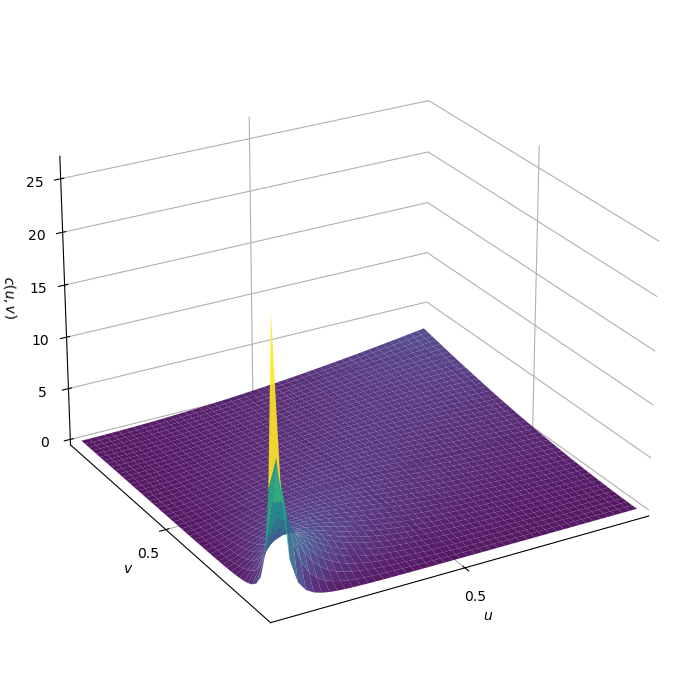

In [19]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(U, V, f, cmap="viridis", edgecolor="none", alpha=0.9)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("white")
ax.yaxis.pane.set_edgecolor("white")
ax.zaxis.pane.set_edgecolor("white")

ax.set_xlabel("$u$")
ax.set_ylabel("$v$")
ax.set_zlabel("$c(u,v)$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([0.5])
ax.set_yticks([0.5])
ax.view_init(elev=25, azim=240)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "clayton_copula_density.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Directory for temporary frames
frames_dir = os.path.join(OUTPUT_DIR, "frames")
os.makedirs(frames_dir, exist_ok=True)

fig = plt.figure(figsize=(8, 6))
fig.patch.set_alpha(0)

ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor((1, 1, 1, 0))

ax.plot_surface(U, V, f, cmap="viridis", edgecolor="none", alpha=0.9)

# Transparent panes
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    axis.pane.set_facecolor((1, 1, 1, 0))
    axis.pane.set_edgecolor((1, 1, 1, 0))

ax.set_xlabel("$u$")
ax.set_ylabel("$v$")
ax.set_zlabel("$c(u,v)$")
# ax.set_title(f"Clayton Copula Density (theta = {THETA})", fontsize=13)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Save transparent PNG frames
n_frames = 72

for i, angle in enumerate(np.linspace(0, 360, n_frames, endpoint=False)):
    ax.view_init(elev=25, azim=angle)

    frame_path = os.path.join(frames_dir, f"frame_{i:03d}.png")
    fig.savefig(
        frame_path,
        dpi=120,
        transparent=True,
        bbox_inches="tight",
        pad_inches=0,
    )

plt.close(fig)

# Assemble GIF
frames = [Image.open(os.path.join(frames_dir, f"frame_{i:03d}.png"))
          for i in range(n_frames)]

# Convert to palette mode while preserving transparency
palette_frames = []
for im in frames:
    im = im.convert("RGBA")
    pal = im.convert("P", palette=Image.ADAPTIVE)
    alpha = im.getchannel("A")
    mask = Image.eval(alpha, lambda a: 255 if a <= 128 else 0)
    pal.paste(255, mask)              # palette index 255 becomes transparent
    pal.info["transparency"] = 255
    palette_frames.append(pal)

gif_path = os.path.join(OUTPUT_DIR, "transparent_clayton_copula_density_rotation.gif")

palette_frames[0].save(
    gif_path,
    save_all=True,
    append_images=palette_frames[1:],
    duration=1000 // 15,
    loop=0,
    transparency=255,
    disposal=2,
)

for f in os.listdir(frames_dir):
    os.remove(os.path.join(frames_dir, f))
os.rmdir(frames_dir)